In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("Advanced_Regression_HousePrice_Dataset_3800.csv")

In [3]:
df.head(5)

,property_id,sale_date,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
0,200001,2014-01-01,2181,6,4,8.1,21,3.8,0,0,4.84,35154898
1,200002,2019-12-01,2383,5,4,5.3,28,10.9,1,1,2.89,26710893
2,200003,2016-10-01,1047,3,3,5.9,7,27.5,0,1,4.04,11216242
3,200004,2013-03-01,1753,4,3,7.0,27,12.1,0,0,3.28,21984310
4,200005,2013-07-01,1728,4,4,10.0,32,1.4,0,1,3.84,25080429


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3800 entries, 0 to 3799
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   property_id       3800 non-null   int64  
 1   sale_date         3800 non-null   str    
 2   area_sqft         3800 non-null   int64  
 3   bedrooms          3800 non-null   int64  
 4   bathrooms         3800 non-null   int64  
 5   location_score    3800 non-null   float64
 6   property_age      3800 non-null   int64  
 7   distance_city_km  3800 non-null   float64
 8   near_school       3800 non-null   int64  
 9   near_metro        3800 non-null   int64  
 10  crime_rate_index  3800 non-null   float64
 11  house_price_inr   3800 non-null   int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 356.4 KB


In [5]:
df.describe()

,property_id,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
count,3800.00000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3.800000e+03
mean,201900.50000,1716.925526,3.428158,2.916316,6.502237,22.537105,13.085132,0.548421,0.472895,4.242911,2.071940e+07
std,1097.10984,582.996559,1.356682,1.133540,1.766945,12.325740,6.537425,0.497715,0.499330,2.045371,8.707465e+06
min,200001.00000,500.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.500000,1.506126e+06
25%,200950.75000,1322.000000,2.000000,2.000000,5.300000,14.000000,8.500000,0.000000,0.000000,2.810000,1.446895e+07
50%,201900.50000,1700.500000,3.000000,3.000000,6.500000,20.000000,13.000000,1.000000,0.000000,4.220000,1.989180e+07
75%,202850.25000,2105.000000,4.000000,4.000000,7.700000,29.000000,17.500000,1.000000,1.000000,5.650000,2.596062e+07
max,203800.00000,3776.000000,7.000000,6.000000,10.000000,80.000000,38.700000,1.000000,1.000000,12.000000,5.930315e+07


In [6]:
df.shape

(3800, 12)

In [7]:
df.isnull().sum()

property_id         0
sale_date           0
area_sqft           0
bedrooms            0
bathrooms           0
location_score      0
property_age        0
distance_city_km    0
near_school         0
near_metro          0
crime_rate_index    0
house_price_inr     0
dtype: int64

In [8]:
numerical_column = df.select_dtypes("number").columns
numerical_column

Index(['property_id', 'area_sqft', 'bedrooms', 'bathrooms', 'location_score',
       'property_age', 'distance_city_km', 'near_school', 'near_metro',
       'crime_rate_index', 'house_price_inr'],
      dtype='str')

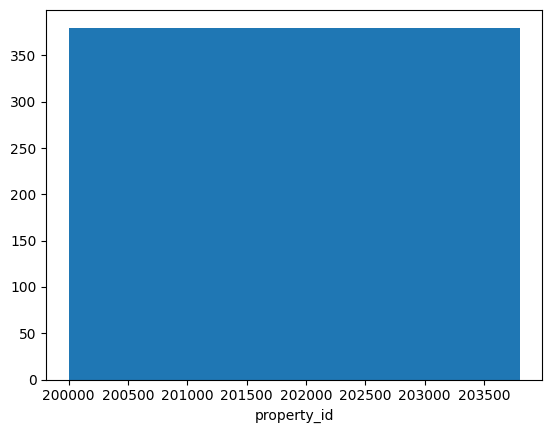

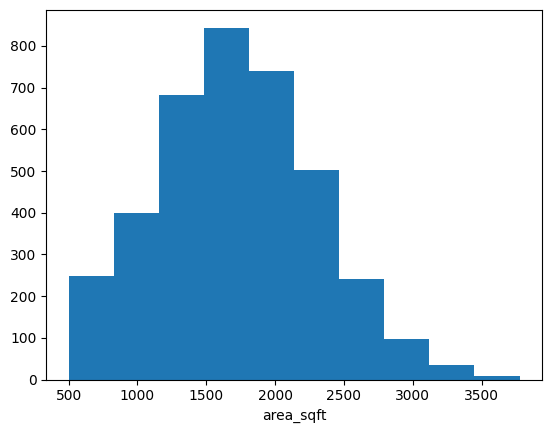

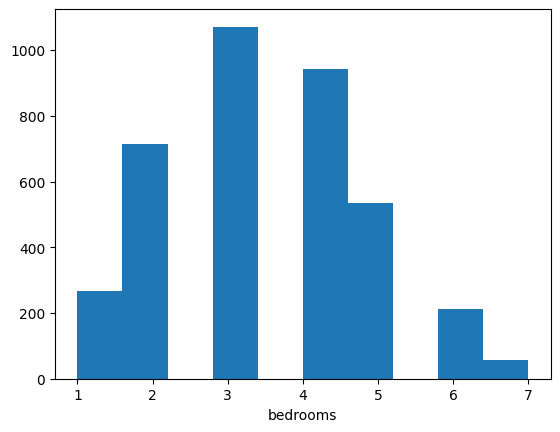

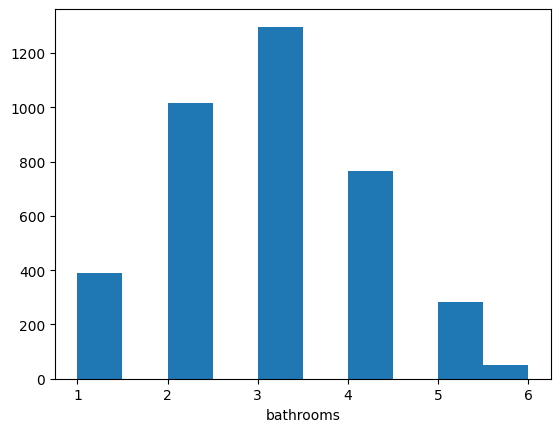

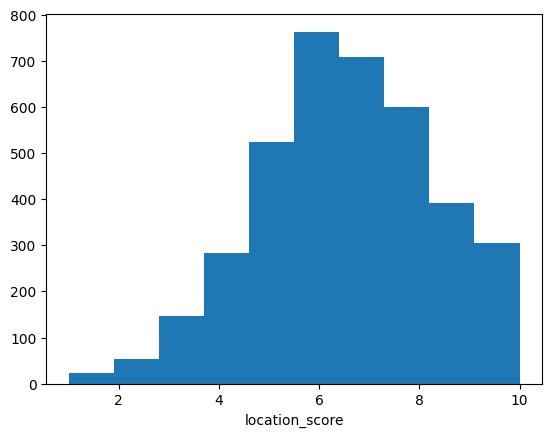

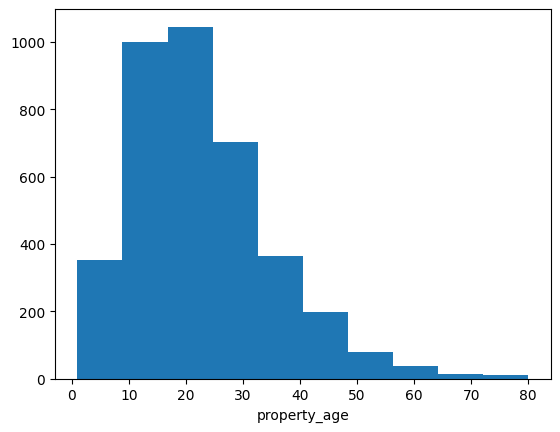

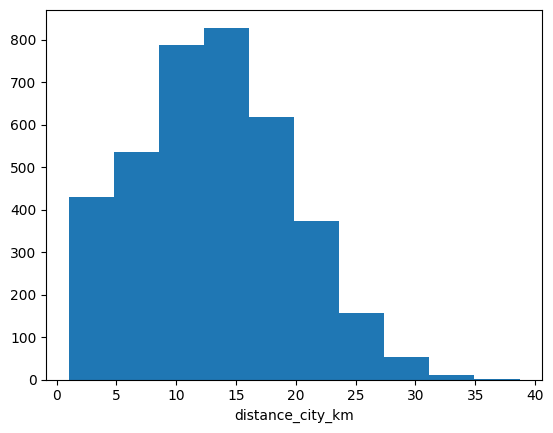

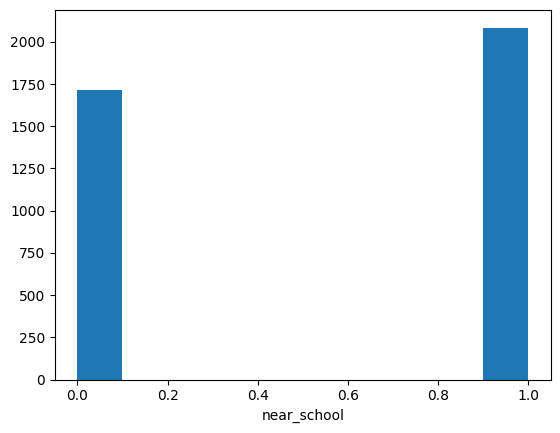

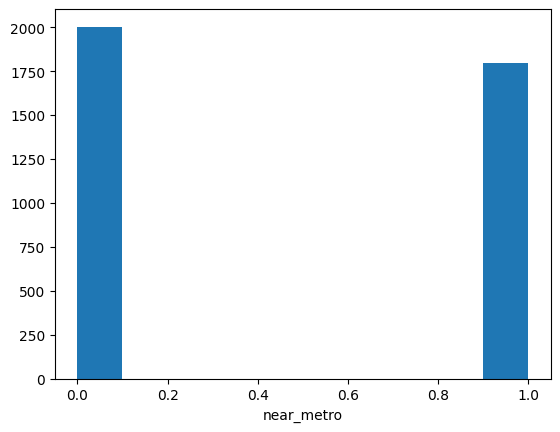

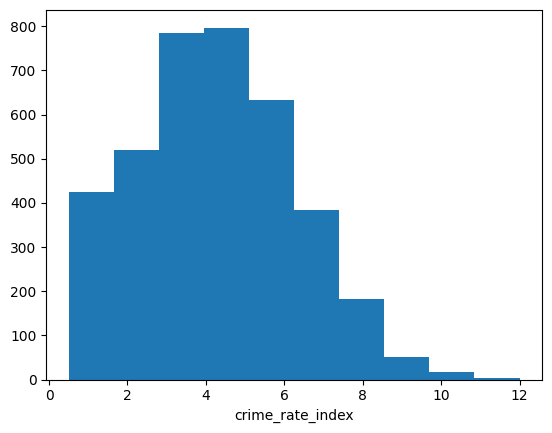

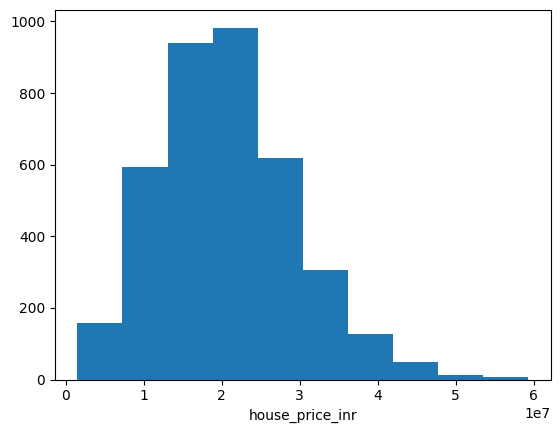

In [9]:
for cols in numerical_column:
    plt.hist(df[cols])
    plt.xlabel(cols)
    plt.show()

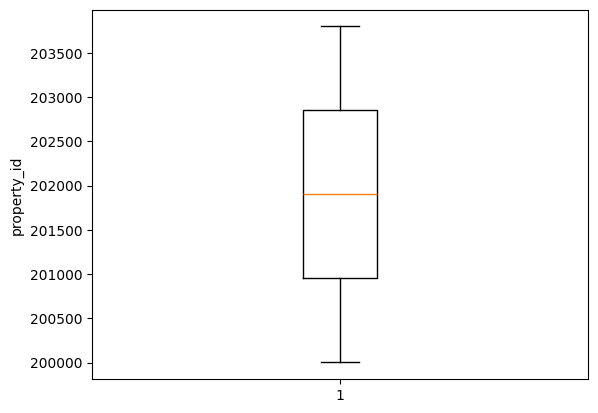

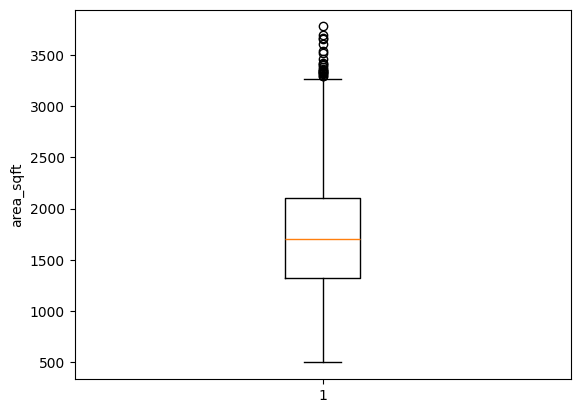

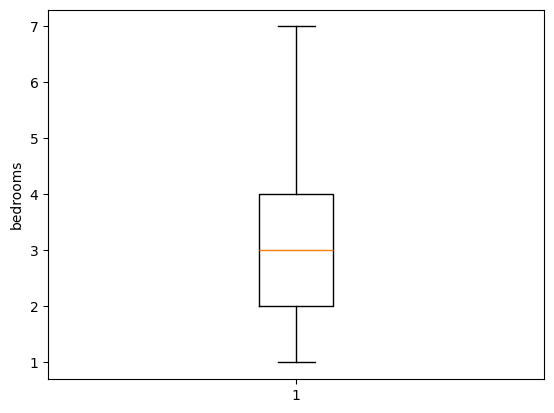

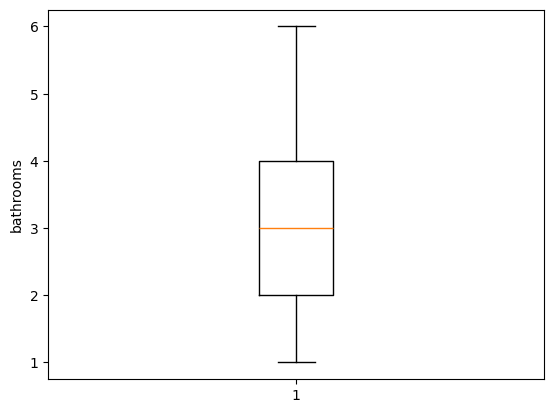

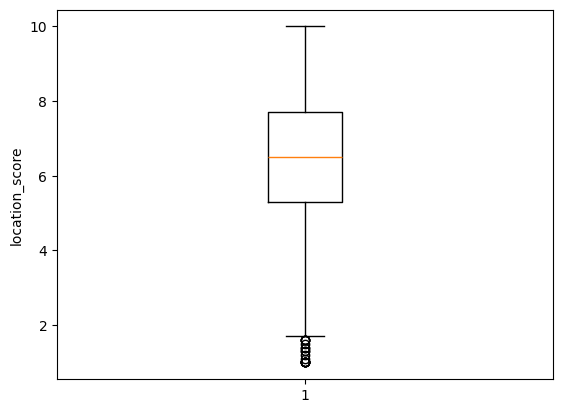

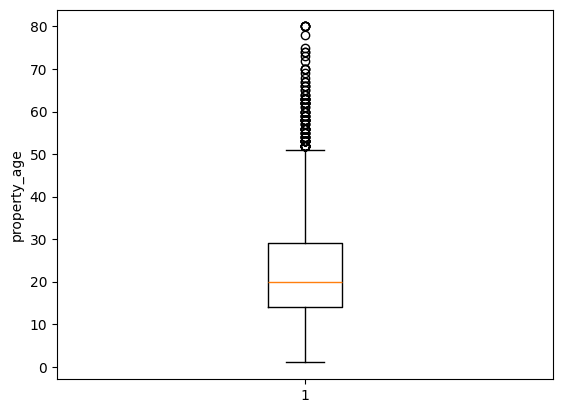

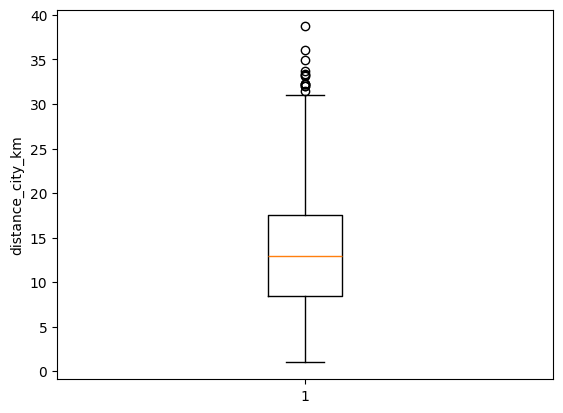

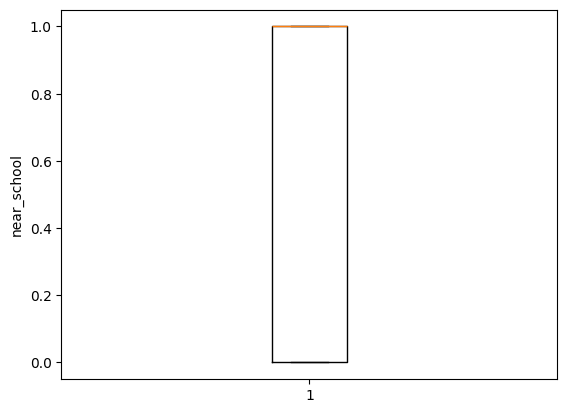

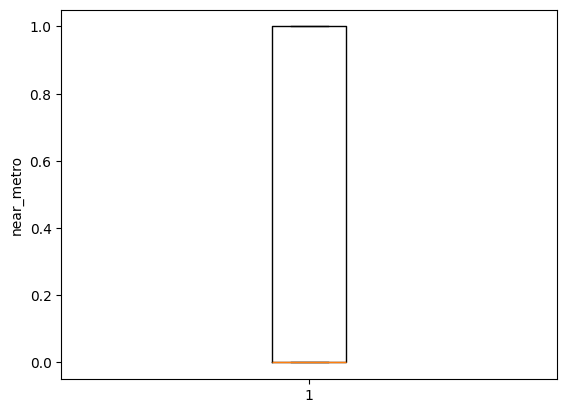

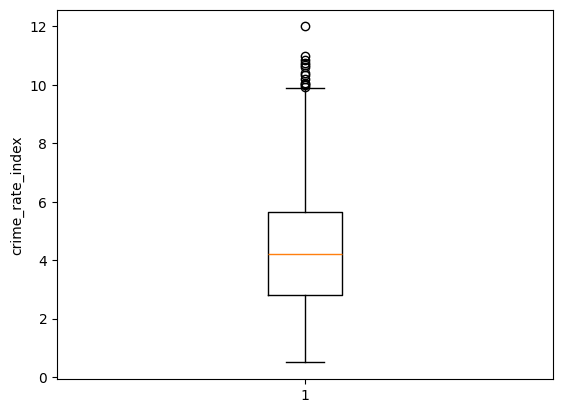

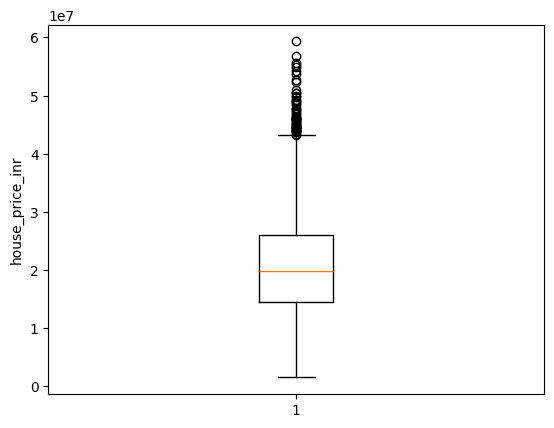

In [10]:
for cols in numerical_column:
    plt.boxplot(df[cols])
    plt.ylabel(cols)
    plt.show()

In [11]:
outliers_column = ['area_sqft', 'bedrooms', 'bathrooms', 'location_score',
       'property_age', 'distance_city_km', 'near_school', 'near_metro',
       'crime_rate_index','house_price_inr']

In [12]:
for cols in outliers_column:

   Q1 = df[cols].quantile(0.25)
   Q3 = df[cols].quantile(0.75)

   IQR = Q3 - Q1

   lower_limit = Q1 - (1.5 * IQR)
   upper_limit = Q3 + (1.5 * IQR)

   df = df[
    (df[cols] >= lower_limit) &
    (df[cols] <= upper_limit)
]

print(df.shape)

(3589, 12)


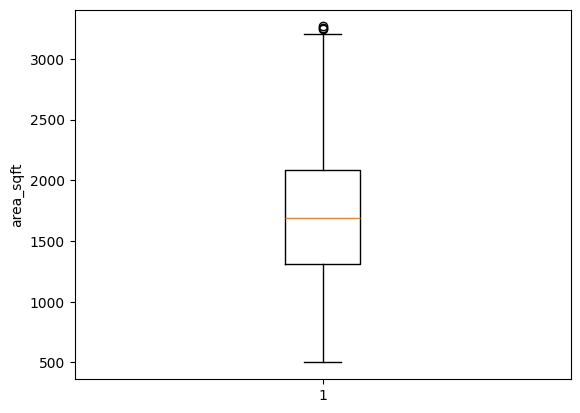

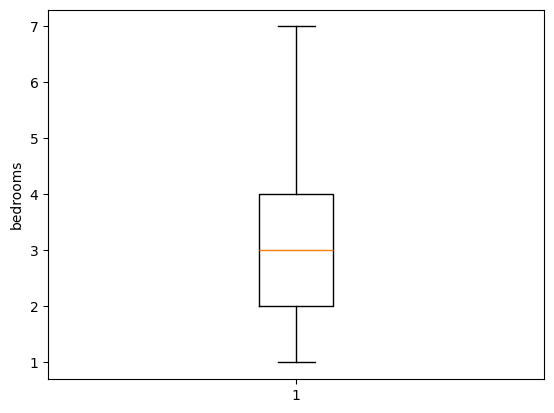

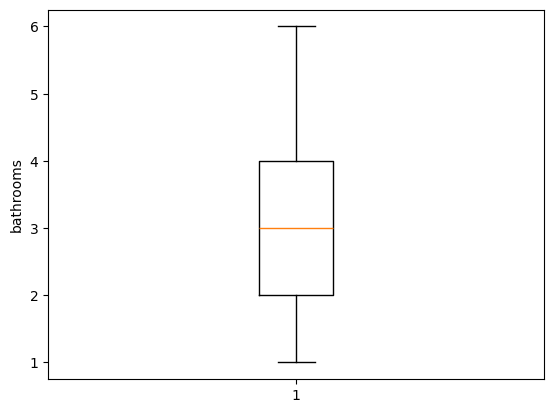

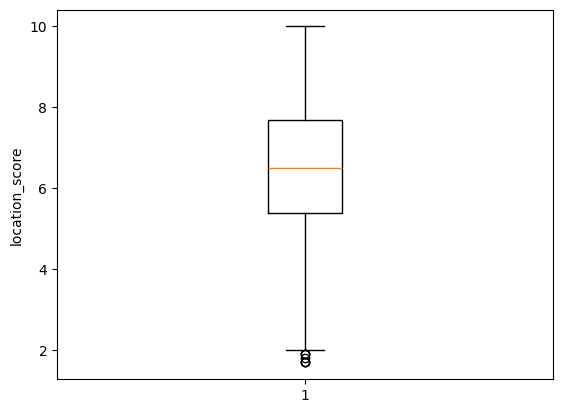

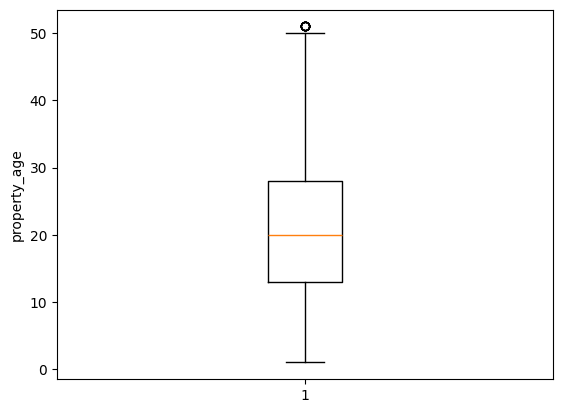

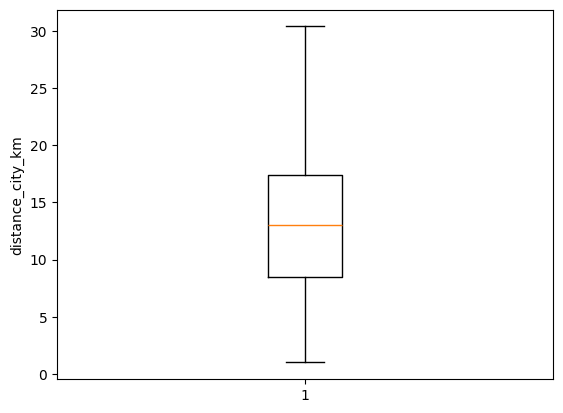

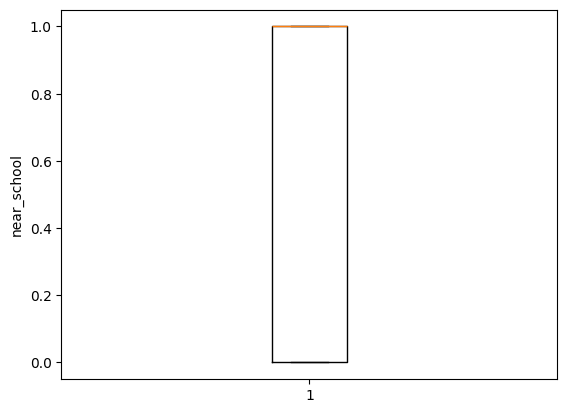

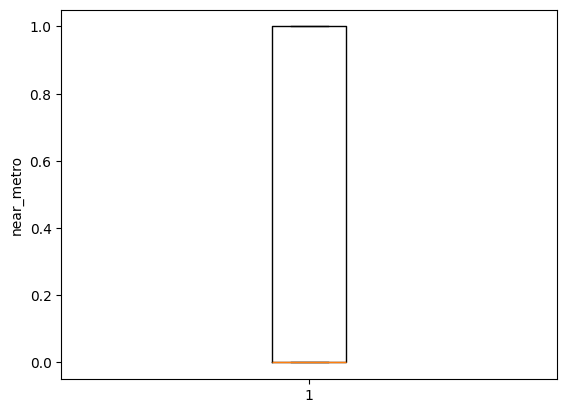

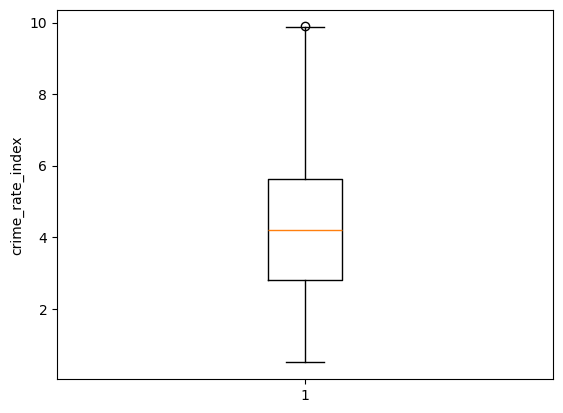

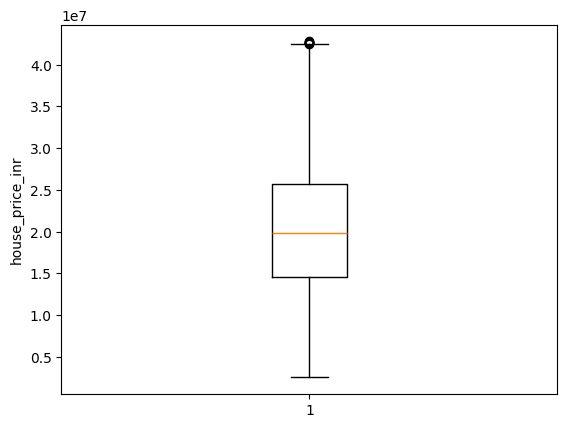

In [13]:
for cols in outliers_column:
    plt.boxplot(df[cols])
    plt.ylabel(cols)
    plt.show()

In [14]:
scaling_column = ['area_sqft', 'bedrooms', 'bathrooms', 'location_score',
       'property_age', 'distance_city_km', 'near_school', 'near_metro',
       'crime_rate_index']

In [15]:
scalar = StandardScaler()

In [16]:
df[scaling_column] = scalar.fit_transform(df[scaling_column])

In [17]:
df.drop(['property_id','sale_date'],axis=1,inplace=True)

In [18]:
df.head(5)

,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
0,0.876693,1.989608,1.008484,0.925295,-0.038259,-1.447797,-1.108065,-0.948655,0.303668,35154898
1,1.238767,1.230524,1.008484,-0.704701,0.619638,-0.330404,0.902474,1.054124,-0.664835,26710893
2,-1.155940,-0.287644,0.106553,-0.355416,-1.354054,2.282091,-1.108065,1.054124,-0.093667,11216242
3,0.109526,0.471440,0.106553,0.284939,0.525653,-0.141549,-1.108065,-0.948655,-0.471135,21984310
4,0.064715,0.471440,1.008484,2.031364,0.995579,-1.825507,-1.108065,1.054124,-0.193000,25080429


In [19]:
df.tail(5)

,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
3795,-1.254524,-0.287644,0.106553,0.517796,0.055726,-0.220239,-1.108065,-0.948655,-0.386701,10901127
3796,1.081031,0.471440,1.008484,-2.160054,0.055726,1.573884,-1.108065,-0.948655,0.571869,20662246
3797,0.641882,-1.046728,-1.697310,1.274580,1.559491,-0.314666,-1.108065,-0.948655,-0.659869,32486165
3798,0.475185,1.989608,1.008484,0.750653,0.055726,-1.856983,-1.108065,-0.948655,0.040434,25004531
3799,0.276224,0.471440,0.106553,0.110297,0.149711,-1.888459,0.902474,-0.948655,1.386405,24138565


In [20]:
df.to_csv("complated_clean_data.csv",index=False)